# Water Segmentation using Multispectral (12-band) Data — U-Net from Scratch

**Workflow:** dataset exploration → band visualization → preprocessing/normalization →
augmentation → U-Net (from scratch, PyTorch) → training → evaluation (IoU, Precision, Recall, F1).

**Assumption:** your `data/` folder (from Drive) has this structure:
```
data/
  images/   -> one file per sample, 12-band (e.g. .tif / .npy), shape (12, H, W) or (H, W, 12)
  labels/   -> one file per sample, binary mask (e.g. .png / .tif / .npy), same H, W
```
Matching image/label pairs are assumed to share the same filename (stem), just different extension/folder.
If your naming differs, adjust `match_pairs()` in the Dataset Setup section — everything else stays the same.


## 1. Setup & Imports

In [1]:
# If running in Colab, mount Drive first
try:
    from google.colab import drive
    drive.mount('/content/drive')
    IN_COLAB = True
except Exception:
    IN_COLAB = False

import os, glob, random
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

# File readers - we try tifffile first (best for multi-band satellite images),
# fall back to PIL/np as needed.
try:
    import tifffile
    HAS_TIFFFILE = True
except ImportError:
    HAS_TIFFFILE = False

from PIL import Image

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", device)


Mounted at /content/drive
Device: cuda


In [4]:
# ==========================
# Extract Dataset
# ==========================
from zipfile import ZipFile

zip_path = "/content/drive/MyDrive/data.zip"
extract_path = "/content/data"

with ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Done extracting!")
print(os.listdir(extract_path))

Done extracting!
['data']


In [7]:
# ==========================
# Dataset Paths
# ==========================

DATA_DIR = "/content/data/data"

IMAGES_DIR = os.path.join(
    DATA_DIR,
    "images"
)

LABELS_DIR = os.path.join(
    DATA_DIR,
    "labels"
)

print("Images dir exists:", os.path.isdir(IMAGES_DIR))
print("Labels dir exists:", os.path.isdir(LABELS_DIR))

Images dir exists: True
Labels dir exists: True


## 2. Dataset Structure Exploration
How many samples, what shape, what format. This also builds the matched
(image, label) file-path pairs used everywhere else in the notebook.

In [8]:
def list_files(folder):
    exts = ('.tif', '.tiff', '.npy', '.png', '.jpg', '.jpeg')
    files = [f for f in sorted(os.listdir(folder)) if f.lower().endswith(exts)]
    return files

image_files = list_files(IMAGES_DIR)
label_files = list_files(LABELS_DIR)

print(f"Number of image files: {len(image_files)}")
print(f"Number of label files: {len(label_files)}")
print("Example image filenames:", image_files[:5])
print("Example label filenames:", label_files[:5])


Number of image files: 306
Number of label files: 456
Example image filenames: ['0.tif', '1.tif', '10.tif', '100.tif', '101.tif']
Example label filenames: ['0.png', '1.png', '10.png', '100.png', '100_184.png']


In [9]:
def stem(filename):
    return os.path.splitext(filename)[0]

def match_pairs(images_dir, labels_dir):
    """Pair image/label files that share the same base filename (stem)."""
    img_map = {stem(f): f for f in list_files(images_dir)}
    lbl_map = {stem(f): f for f in list_files(labels_dir)}
    common = sorted(set(img_map) & set(lbl_map))
    missing_lbl = sorted(set(img_map) - set(lbl_map))
    missing_img = sorted(set(lbl_map) - set(img_map))
    if missing_lbl:
        print(f"WARNING: {len(missing_lbl)} images have no matching label (e.g. {missing_lbl[:3]})")
    if missing_img:
        print(f"WARNING: {len(missing_img)} labels have no matching image (e.g. {missing_img[:3]})")
    pairs = [(os.path.join(images_dir, img_map[s]), os.path.join(labels_dir, lbl_map[s])) for s in common]
    return pairs

pairs = match_pairs(IMAGES_DIR, LABELS_DIR)
print(f"Matched pairs: {len(pairs)}")


Matched pairs: 306


In [10]:
def load_image(path):
    """Load a multi-band image and return array as (C, H, W) float32."""
    ext = os.path.splitext(path)[1].lower()
    if ext in ('.tif', '.tiff') and HAS_TIFFFILE:
        arr = tifffile.imread(path)
    elif ext == '.npy':
        arr = np.load(path)
    else:
        arr = np.array(Image.open(path))
    arr = np.asarray(arr).astype(np.float32)
    # Normalize axis order to (C, H, W)
    if arr.ndim == 2:
        arr = arr[None, ...]
    elif arr.ndim == 3:
        # Heuristic: channel dim is whichever axis is smallest (bands << H, W)
        if arr.shape[0] not in (arr.shape[-1],) and arr.shape[-1] < arr.shape[0] and arr.shape[-1] <= 13:
            arr = np.transpose(arr, (2, 0, 1))  # (H,W,C) -> (C,H,W)
    return arr

def load_label(path):
    """Load a binary mask and return array as (H, W) with values {0,1}."""
    ext = os.path.splitext(path)[1].lower()
    if ext in ('.tif', '.tiff') and HAS_TIFFFILE:
        arr = tifffile.imread(path)
    elif ext == '.npy':
        arr = np.load(path)
    else:
        arr = np.array(Image.open(path).convert('L'))
    arr = np.asarray(arr)
    if arr.ndim == 3:
        arr = arr[..., 0]
    # Binarize (handles masks stored as 0/255 or 0/1)
    arr = (arr > (arr.max() / 2 if arr.max() > 1 else 0.5)).astype(np.float32) if arr.max() > 0 else arr.astype(np.float32)
    return arr

# Inspect one sample
sample_img_path, sample_lbl_path = pairs[0]
sample_img = load_image(sample_img_path)
sample_lbl = load_label(sample_lbl_path)
print("Image shape (C,H,W):", sample_img.shape, "| dtype:", sample_img.dtype)
print("Label shape (H,W):", sample_lbl.shape, "| unique values:", np.unique(sample_lbl))


Image shape (C,H,W): (12, 128, 128) | dtype: float32
Label shape (H,W): (128, 128) | unique values: [0. 1.]


## 3. Visualize All 12 Spectral Bands
Developing intuition for what each band captures. Band names follow the common Sentinel-2-style 12-band convention — **edit `BAND_NAMES` if your dataset documents different bands/order**.

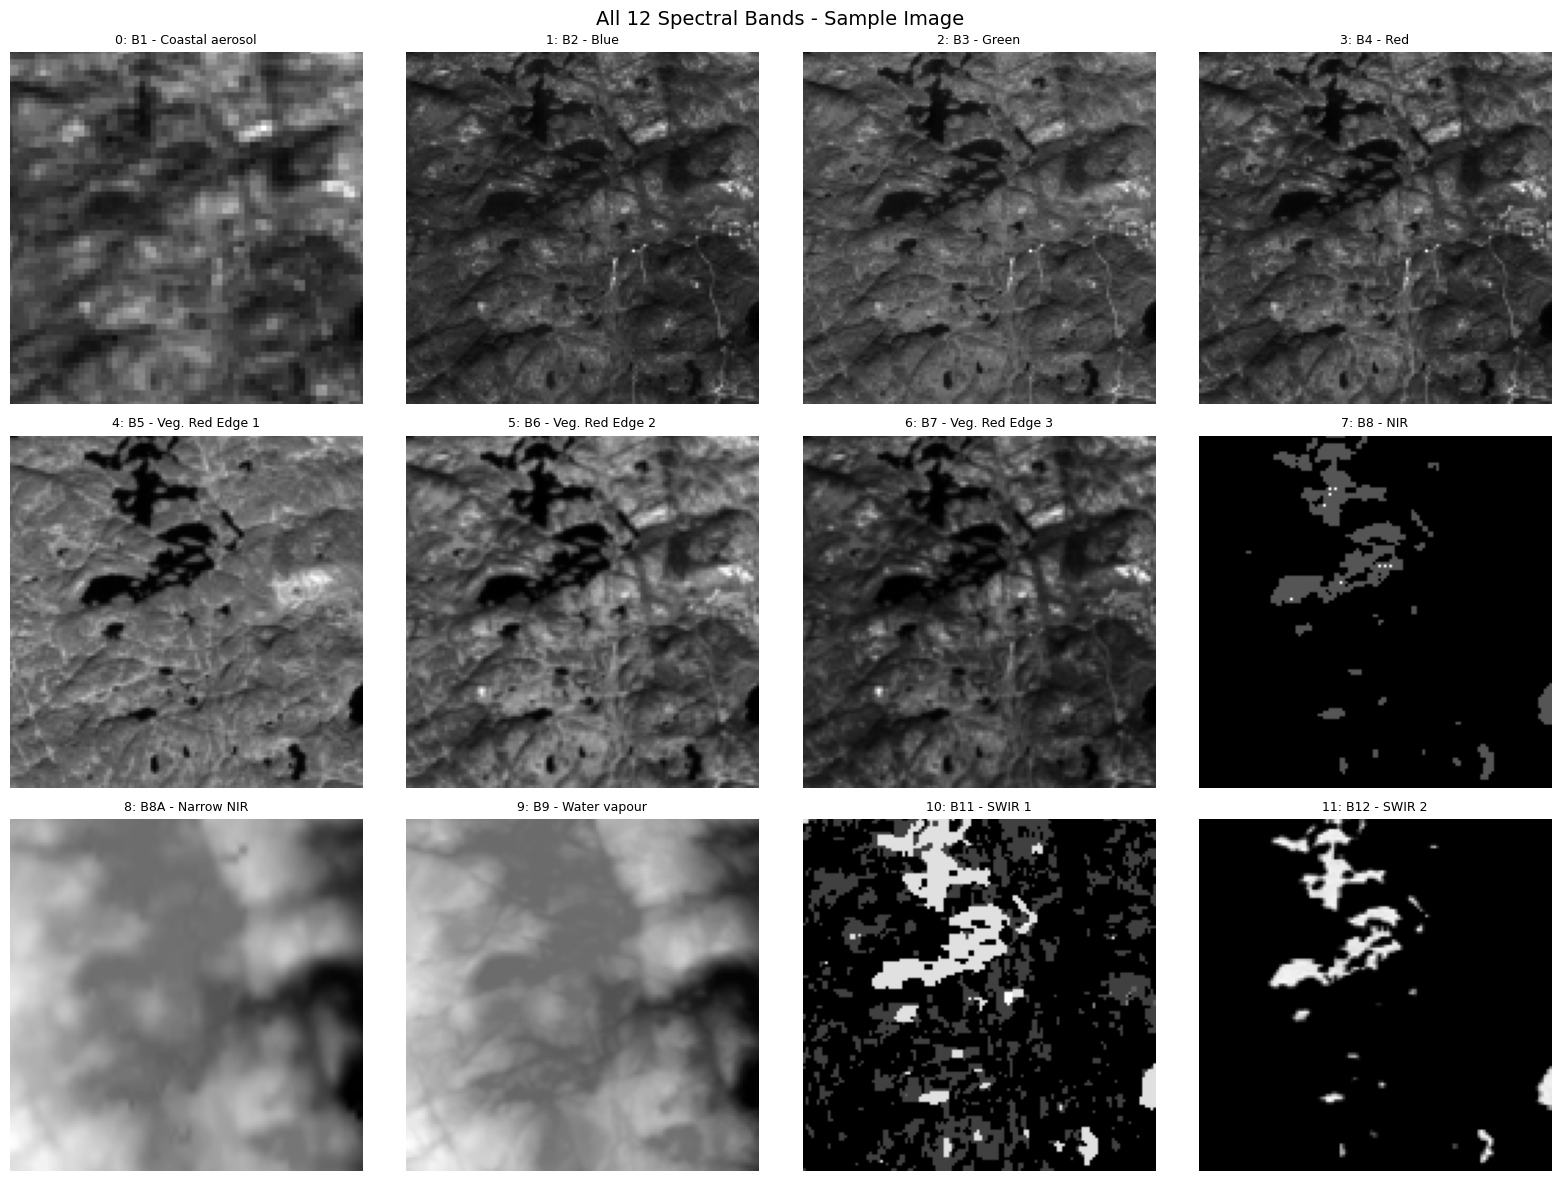

In [11]:
BAND_NAMES = [
    'B1 - Coastal aerosol', 'B2 - Blue', 'B3 - Green', 'B4 - Red',
    'B5 - Veg. Red Edge 1', 'B6 - Veg. Red Edge 2', 'B7 - Veg. Red Edge 3',
    'B8 - NIR', 'B8A - Narrow NIR', 'B9 - Water vapour',
    'B11 - SWIR 1', 'B12 - SWIR 2'
]
assert sample_img.shape[0] == 12, f"Expected 12 bands, got {sample_img.shape[0]}"

fig, axes = plt.subplots(3, 4, figsize=(16, 12))
for i, ax in enumerate(axes.flat):
    band = sample_img[i]
    ax.imshow(band, cmap='gray')
    ax.set_title(f"{i}: {BAND_NAMES[i]}", fontsize=9)
    ax.axis('off')
plt.suptitle("All 12 Spectral Bands - Sample Image", fontsize=14)
plt.tight_layout()
plt.show()


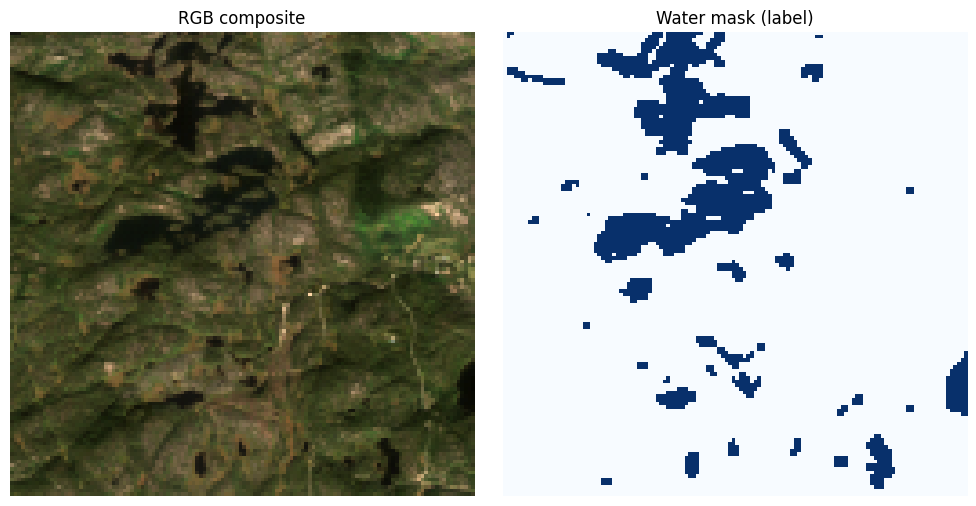

In [12]:
# RGB composite (bands 3,2,1 -> Red, Green, Blue) vs. the water mask, side by side
rgb = sample_img[[3, 2, 1]].transpose(1, 2, 0)
rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min() + 1e-8)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(rgb); axes[0].set_title("RGB composite"); axes[0].axis('off')
axes[1].imshow(sample_lbl, cmap='Blues'); axes[1].set_title("Water mask (label)"); axes[1].axis('off')
plt.tight_layout(); plt.show()


## 4. Label Distribution (Class Balance)
Water segmentation datasets are usually imbalanced (much more "non-water" than "water"), which matters for loss-function choice and metric interpretation.

Sampled 200 labels
Water pixels: 30.14%  |  Non-water pixels: 69.86%


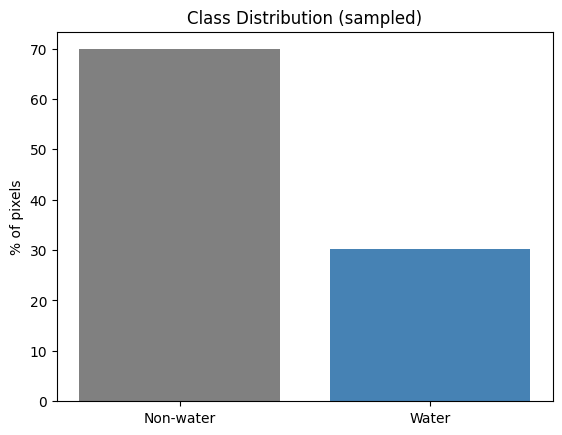

In [13]:
water_px, total_px = 0, 0
sample_n = min(len(pairs), 200)  # sample a subset for speed on large datasets
for _, lbl_path in random.sample(pairs, sample_n):
    lbl = load_label(lbl_path)
    water_px += lbl.sum()
    total_px += lbl.size

water_pct = 100 * water_px / total_px
print(f"Sampled {sample_n} labels")
print(f"Water pixels: {water_pct:.2f}%  |  Non-water pixels: {100-water_pct:.2f}%")

plt.bar(['Non-water', 'Water'], [100 - water_pct, water_pct], color=['gray', 'steelblue'])
plt.ylabel('% of pixels'); plt.title('Class Distribution (sampled)')
plt.show()


## 5. Preprocessing: Per-Band Normalization
Each of the 12 bands has a different sensor and value range, so we normalize **per band** (not globally) using
mean/std computed across the training set. Output is verified to be `(12, 128, 128)`.

In [14]:
IMG_SIZE = 128

def resize_chw(arr, size=IMG_SIZE):
    """Resize a (C,H,W) array to (C,size,size) using PIL per-channel (nearest for masks handled separately)."""
    c = arr.shape[0]
    out = np.zeros((c, size, size), dtype=np.float32)
    for i in range(c):
        img = Image.fromarray(arr[i])
        img = img.resize((size, size), resample=Image.BILINEAR)
        out[i] = np.array(img, dtype=np.float32)
    return out

def resize_mask(mask, size=IMG_SIZE):
    img = Image.fromarray(mask.astype(np.uint8))
    img = img.resize((size, size), resample=Image.NEAREST)
    return np.array(img, dtype=np.float32)


In [15]:
# Compute per-band mean/std over a sample of the training data
def compute_band_stats(pairs, n_samples=100):
    n_samples = min(n_samples, len(pairs))
    sums = np.zeros(12); sq_sums = np.zeros(12); count = 0
    for img_path, _ in random.sample(pairs, n_samples):
        arr = load_image(img_path)
        arr = arr.reshape(12, -1)
        sums += arr.sum(axis=1)
        sq_sums += (arr ** 2).sum(axis=1)
        count += arr.shape[1]
    mean = sums / count
    std = np.sqrt(sq_sums / count - mean ** 2) + 1e-8
    return mean.astype(np.float32), std.astype(np.float32)

BAND_MEAN, BAND_STD = compute_band_stats(pairs)
print("Per-band mean:", np.round(BAND_MEAN, 2))
print("Per-band std :", np.round(BAND_STD, 2))


Per-band mean: [ 379.77  474.45  797.96  938.63 2125.13 1949.59 1320.17  102.35  158.16
  280.88   33.8     7.97]
Per-band std : [ 242.94  293.29  381.82  540.62 1044.98 1166.88  920.93   47.06 1175.16
  395.68   18.86   25.12]


In [16]:
def preprocess_image(arr, mean=BAND_MEAN, std=BAND_STD, size=IMG_SIZE):
    arr = resize_chw(arr, size)
    arr = (arr - mean[:, None, None]) / std[:, None, None]
    return arr.astype(np.float32)

# sanity check
out = preprocess_image(sample_img)
print("Preprocessed shape:", out.shape)
assert out.shape == (12, IMG_SIZE, IMG_SIZE), "Shape mismatch!"
print("Per-band mean after normalization (~0):", np.round(out.mean(axis=(1,2)), 2))


Preprocessed shape: (12, 128, 128)
Per-band mean after normalization (~0): [-0.85 -1.05 -1.23 -1.13 -0.17 -0.56 -0.7  -0.77  0.08  0.03 -0.7  -0.13]


## 6. Augmentation
Simple, dependency-light augmentations implemented directly on numpy arrays so they apply identically
to all 12 bands *and* the mask (spatial transforms only — no color jitter, since band values aren't RGB colors).
Includes: horizontal/vertical flip, 90° rotations, and random crop-and-resize.

In [17]:
class WaterAugmentor:
    def __init__(self, p_flip=0.5, p_rotate=0.5, p_crop=0.3):
        self.p_flip = p_flip
        self.p_rotate = p_rotate
        self.p_crop = p_crop

    def __call__(self, img, mask):
        # img: (C,H,W) float32, mask: (H,W) float32
        if random.random() < self.p_flip:
            img = img[:, :, ::-1].copy(); mask = mask[:, ::-1].copy()
        if random.random() < self.p_flip:
            img = img[:, ::-1, :].copy(); mask = mask[::-1, :].copy()
        if random.random() < self.p_rotate:
            k = random.choice([1, 2, 3])
            img = np.rot90(img, k, axes=(1, 2)).copy()
            mask = np.rot90(mask, k, axes=(0, 1)).copy()
        if random.random() < self.p_crop:
            h, w = mask.shape
            ch, cw = int(h * 0.8), int(w * 0.8)
            top = random.randint(0, h - ch)
            left = random.randint(0, w - cw)
            img_c = img[:, top:top+ch, left:left+cw]
            mask_c = mask[top:top+ch, left:left+cw]
            img = resize_chw(img_c, h)
            mask = resize_mask(mask_c, h)
        return img, mask

train_augmentor = WaterAugmentor()


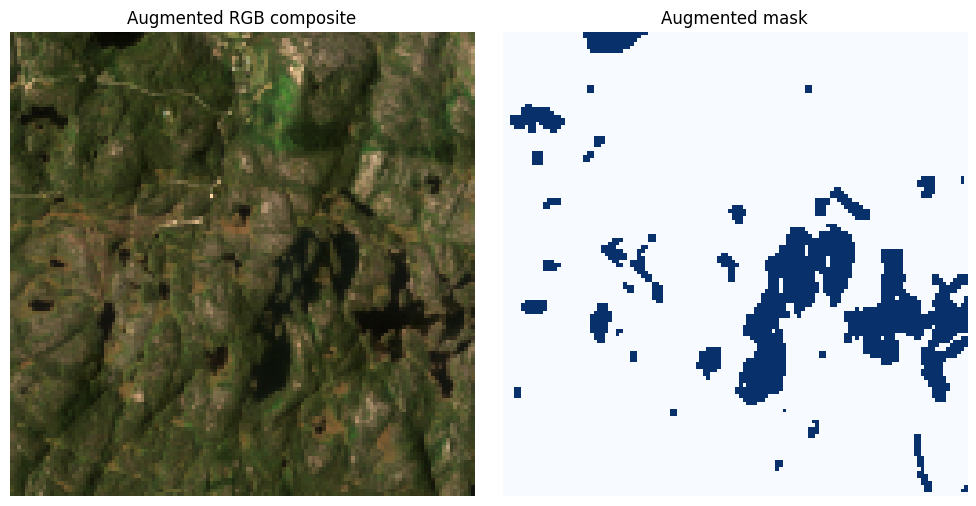

In [18]:
# Visualize augmentation effect on RGB composite + mask
aug_img, aug_mask = train_augmentor(sample_img.copy(), sample_lbl.copy())
rgb_aug = aug_img[[3, 2, 1]].transpose(1, 2, 0)
rgb_aug = (rgb_aug - rgb_aug.min()) / (rgb_aug.max() - rgb_aug.min() + 1e-8)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(rgb_aug); axes[0].set_title("Augmented RGB composite"); axes[0].axis('off')
axes[1].imshow(aug_mask, cmap='Blues'); axes[1].set_title("Augmented mask"); axes[1].axis('off')
plt.tight_layout(); plt.show()


## 7. PyTorch Dataset & DataLoaders
Train/val split, applies preprocessing (+ augmentation only for the training split).

In [19]:
class WaterDataset(Dataset):
    def __init__(self, pairs, augment=False):
        self.pairs = pairs
        self.augment = augment
        self.augmentor = WaterAugmentor() if augment else None

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        img_path, lbl_path = self.pairs[idx]
        img = load_image(img_path)
        lbl = load_label(lbl_path)

        img = resize_chw(img, IMG_SIZE)
        lbl = resize_mask(lbl, IMG_SIZE)

        if self.augment:
            img, lbl = self.augmentor(img, lbl)

        img = (img - BAND_MEAN[:, None, None]) / BAND_STD[:, None, None]

        img_t = torch.from_numpy(img.astype(np.float32))
        lbl_t = torch.from_numpy(lbl.astype(np.float32)).unsqueeze(0)  # (1,H,W)
        return img_t, lbl_t


In [20]:
random.shuffle(pairs)
split = int(0.85 * len(pairs))
train_pairs, val_pairs = pairs[:split], pairs[split:]
print(f"Train samples: {len(train_pairs)} | Val samples: {len(val_pairs)}")

train_ds = WaterDataset(train_pairs, augment=True)
val_ds = WaterDataset(val_pairs, augment=False)

BATCH_SIZE = 8
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

xb, yb = next(iter(train_loader))
print("Batch image shape:", xb.shape, "| Batch mask shape:", yb.shape)


Train samples: 260 | Val samples: 46
Batch image shape: torch.Size([8, 12, 128, 128]) | Batch mask shape: torch.Size([8, 1, 128, 128])


## 8. U-Net (from scratch)
Classic encoder–decoder with skip connections: the encoder downsamples and extracts increasingly abstract
features, the decoder upsamples back to full resolution, and skip connections re-inject fine spatial detail
lost during downsampling — essential for pixel-accurate boundaries in segmentation.

In [21]:
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1), nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
        )
    def forward(self, x):
        return self.block(x)

class UNet(nn.Module):
    def __init__(self, in_channels=12, out_channels=1, base=32):
        super().__init__()
        self.enc1 = DoubleConv(in_channels, base)
        self.enc2 = DoubleConv(base, base*2)
        self.enc3 = DoubleConv(base*2, base*4)
        self.enc4 = DoubleConv(base*4, base*8)
        self.pool = nn.MaxPool2d(2)

        self.bottleneck = DoubleConv(base*8, base*16)

        self.up4 = nn.ConvTranspose2d(base*16, base*8, 2, stride=2)
        self.dec4 = DoubleConv(base*16, base*8)
        self.up3 = nn.ConvTranspose2d(base*8, base*4, 2, stride=2)
        self.dec3 = DoubleConv(base*8, base*4)
        self.up2 = nn.ConvTranspose2d(base*4, base*2, 2, stride=2)
        self.dec2 = DoubleConv(base*4, base*2)
        self.up1 = nn.ConvTranspose2d(base*2, base, 2, stride=2)
        self.dec1 = DoubleConv(base*2, base)

        self.out_conv = nn.Conv2d(base, out_channels, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))
        b = self.bottleneck(self.pool(e4))

        d4 = self.up4(b); d4 = self.dec4(torch.cat([d4, e4], dim=1))
        d3 = self.up3(d4); d3 = self.dec3(torch.cat([d3, e3], dim=1))
        d2 = self.up2(d3); d2 = self.dec2(torch.cat([d2, e2], dim=1))
        d1 = self.up1(d2); d1 = self.dec1(torch.cat([d1, e1], dim=1))

        return self.out_conv(d1)  # logits, shape (B,1,H,W)

model = UNet(in_channels=12, out_channels=1).to(device)
n_params = sum(p.numel() for p in model.parameters())
print(f"U-Net parameters: {n_params:,}")

# sanity check forward pass
with torch.no_grad():
    test_out = model(xb.to(device))
    print("Output shape:", test_out.shape)


U-Net parameters: 7,768,577
Output shape: torch.Size([8, 1, 128, 128])


## 9. Loss & Metrics
BCE + Dice loss (helps with class imbalance seen in section 4). Metrics: IoU, Precision, Recall, F1 on the water class.

In [22]:
class BCEDiceLoss(nn.Module):
    def __init__(self, smooth=1.0):
        super().__init__()
        self.bce = nn.BCEWithLogitsLoss()
        self.smooth = smooth

    def forward(self, logits, target):
        bce_loss = self.bce(logits, target)
        probs = torch.sigmoid(logits)
        probs_f = probs.view(probs.size(0), -1)
        target_f = target.view(target.size(0), -1)
        intersection = (probs_f * target_f).sum(1)
        dice = (2 * intersection + self.smooth) / (probs_f.sum(1) + target_f.sum(1) + self.smooth)
        dice_loss = 1 - dice.mean()
        return bce_loss + dice_loss

@torch.no_grad()
def compute_metrics(logits, target, threshold=0.5, eps=1e-7):
    preds = (torch.sigmoid(logits) > threshold).float()
    tp = (preds * target).sum().item()
    fp = (preds * (1 - target)).sum().item()
    fn = ((1 - preds) * target).sum().item()

    iou = tp / (tp + fp + fn + eps)
    precision = tp / (tp + fp + eps)
    recall = tp / (tp + fn + eps)
    f1 = 2 * precision * recall / (precision + recall + eps)
    return {'iou': iou, 'precision': precision, 'recall': recall, 'f1': f1}


## 10. Training Loop

In [23]:
EPOCHS = 20
LR = 1e-3

criterion = BCEDiceLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

history = {'train_loss': [], 'val_loss': [], 'val_iou': [], 'val_f1': []}
best_val_iou = 0.0

for epoch in range(1, EPOCHS + 1):
    # ---- train ----
    model.train()
    train_loss = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * xb.size(0)
    train_loss /= len(train_ds)

    # ---- validate ----
    model.eval()
    val_loss = 0.0
    agg = {'iou': 0, 'precision': 0, 'recall': 0, 'f1': 0}
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            loss = criterion(logits, yb)
            val_loss += loss.item() * xb.size(0)
            m = compute_metrics(logits, yb)
            for k in agg: agg[k] += m[k] * xb.size(0)
    val_loss /= len(val_ds)
    for k in agg: agg[k] /= len(val_ds)

    scheduler.step(val_loss)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_iou'].append(agg['iou'])
    history['val_f1'].append(agg['f1'])

    print(f"Epoch {epoch:02d}/{EPOCHS} | train_loss={train_loss:.4f} val_loss={val_loss:.4f} "
          f"val_IoU={agg['iou']:.4f} val_Precision={agg['precision']:.4f} "
          f"val_Recall={agg['recall']:.4f} val_F1={agg['f1']:.4f}")

    if agg['iou'] > best_val_iou:
        best_val_iou = agg['iou']
        torch.save(model.state_dict(), 'best_unet_water.pth')

print(f"\nBest validation IoU: {best_val_iou:.4f}")


Epoch 01/20 | train_loss=1.0545 val_loss=0.9120 val_IoU=0.6251 val_Precision=0.8154 val_Recall=0.7221 val_F1=0.7527
Epoch 02/20 | train_loss=0.9301 val_loss=0.8989 val_IoU=0.5844 val_Precision=0.7108 val_Recall=0.7714 val_F1=0.7039
Epoch 03/20 | train_loss=0.8875 val_loss=0.8164 val_IoU=0.6270 val_Precision=0.7986 val_Recall=0.7565 val_F1=0.7528
Epoch 04/20 | train_loss=0.8605 val_loss=0.7546 val_IoU=0.6501 val_Precision=0.8661 val_Recall=0.7333 val_F1=0.7760
Epoch 05/20 | train_loss=0.8341 val_loss=0.7831 val_IoU=0.6073 val_Precision=0.7547 val_Recall=0.7674 val_F1=0.7393
Epoch 06/20 | train_loss=0.8512 val_loss=0.7413 val_IoU=0.6464 val_Precision=0.8946 val_Recall=0.7069 val_F1=0.7730
Epoch 07/20 | train_loss=0.8197 val_loss=0.7434 val_IoU=0.6664 val_Precision=0.8974 val_Recall=0.7228 val_F1=0.7909
Epoch 08/20 | train_loss=0.7964 val_loss=0.7309 val_IoU=0.6444 val_Precision=0.8512 val_Recall=0.7291 val_F1=0.7751
Epoch 09/20 | train_loss=0.8044 val_loss=0.7310 val_IoU=0.6373 val_Preci

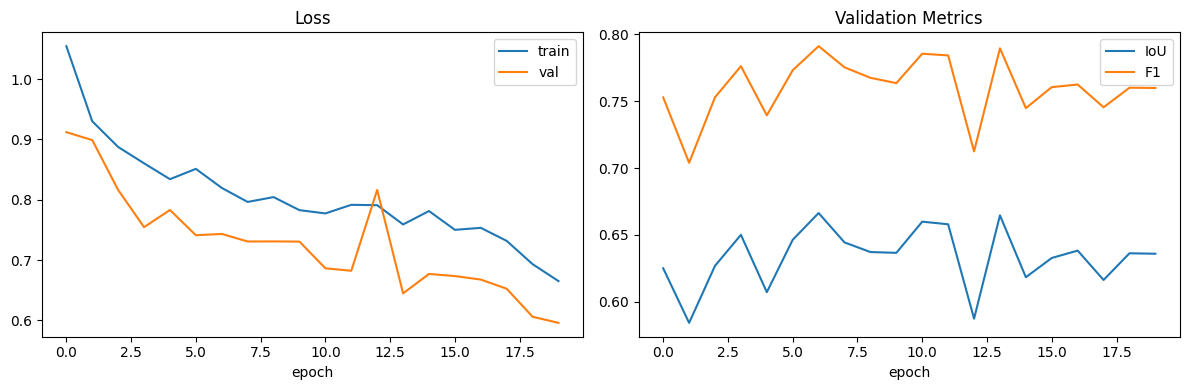

In [24]:
# Loss / metric curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history['train_loss'], label='train'); axes[0].plot(history['val_loss'], label='val')
axes[0].set_title('Loss'); axes[0].set_xlabel('epoch'); axes[0].legend()
axes[1].plot(history['val_iou'], label='IoU'); axes[1].plot(history['val_f1'], label='F1')
axes[1].set_title('Validation Metrics'); axes[1].set_xlabel('epoch'); axes[1].legend()
plt.tight_layout(); plt.show()


## 11. Final Evaluation & Qualitative Check

In [25]:
model.load_state_dict(torch.load('best_unet_water.pth'))
model.eval()

agg = {'iou': 0, 'precision': 0, 'recall': 0, 'f1': 0}
with torch.no_grad():
    for xb, yb in val_loader:
        xb, yb = xb.to(device), yb.to(device)
        logits = model(xb)
        m = compute_metrics(logits, yb)
        for k in agg: agg[k] += m[k] * xb.size(0)
for k in agg: agg[k] /= len(val_ds)

print("Final validation metrics (best checkpoint):")
for k, v in agg.items():
    print(f"  {k.capitalize():10s}: {v:.4f}")


Final validation metrics (best checkpoint):
  Iou       : 0.6664
  Precision : 0.8974
  Recall    : 0.7228
  F1        : 0.7909


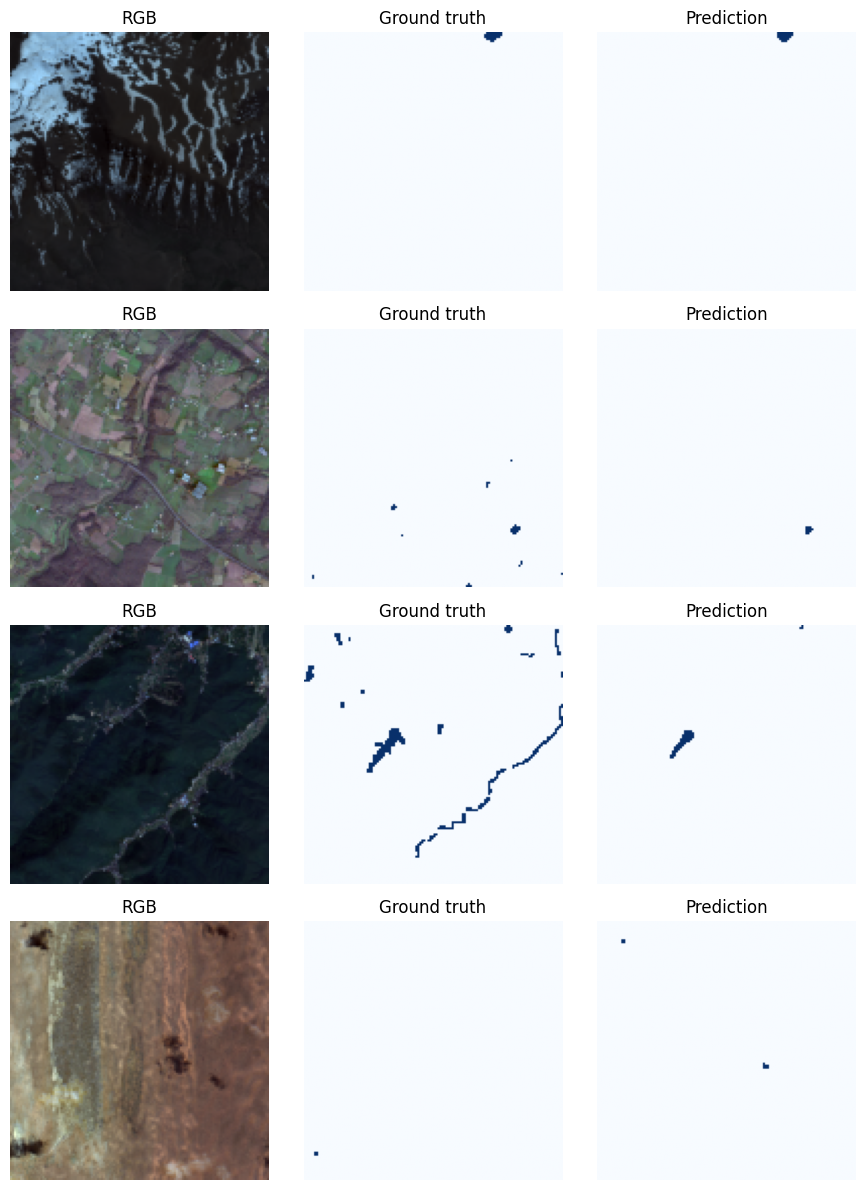

In [26]:
# Visualize predictions on a few validation samples
xb, yb = next(iter(val_loader))
with torch.no_grad():
    preds = (torch.sigmoid(model(xb.to(device))) > 0.5).float().cpu()

n_show = min(4, xb.size(0))
fig, axes = plt.subplots(n_show, 3, figsize=(9, 3*n_show))
for i in range(n_show):
    rgb = xb[i][[3, 2, 1]].numpy().transpose(1, 2, 0)
    rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min() + 1e-8)
    axes[i,0].imshow(rgb); axes[i,0].set_title('RGB'); axes[i,0].axis('off')
    axes[i,1].imshow(yb[i,0], cmap='Blues'); axes[i,1].set_title('Ground truth'); axes[i,1].axis('off')
    axes[i,2].imshow(preds[i,0], cmap='Blues'); axes[i,2].set_title('Prediction'); axes[i,2].axis('off')
plt.tight_layout(); plt.show()
